# » `Dependencias`:

In [ ]:
# !pip install plotly
# !pip install sqlalchemy
# !pip install numpy
# !pip install matplotlib

In [1]:
import pandas as pd
from sqlalchemy import create_engine
import numpy as np
import re
import matplotlib.pyplot as plt
# import cufflinks as cf
# from IPython.display import display, HTML

# cf.set_config_file

## 1. Conección → SIM(172.27.0.124)

In [2]:
# spring.datasource.url = jdbc:sqlserver://172.27.250.27;databaseName=SIRIM
SERVER = '172.27.0.124' # '172.27.0.242'
#DRIVER = 'SQL Server Native Client 11.0'
DRIVER = 'ODBC Driver 17 for SQL Server'
DATABASE = 'SIM'
USERNAME = 'userestadistica' # 'udesa'
PASSWORD = '$Us3R_3sT4d1sTic4$' # 'DESARROLLO2006'
DATABASE_CONNECTION = f'mssql://{USERNAME}:{PASSWORD}@{SERVER}/{DATABASE}?driver={DRIVER}'

engine = create_engine(DATABASE_CONNECTION)
connection = engine.connect()

## 2. Métodos genérico:

In [3]:
def get_query_sql(query):
  try:
    df = pd.read_sql(query, connection)
    return df
  except:
    print('¡Ocurrió un error!')

## 3. Visualización de datos: `INF-AGO2024`

### 3.1 1. 1. Se define como regla que, la dependencia A.I.J.C.H. únicamente debe registrar transporte fluvial.

In [4]:
# Extracción
df_1 = pd.read_excel('./data/A1.xlsx')

<Axes: >

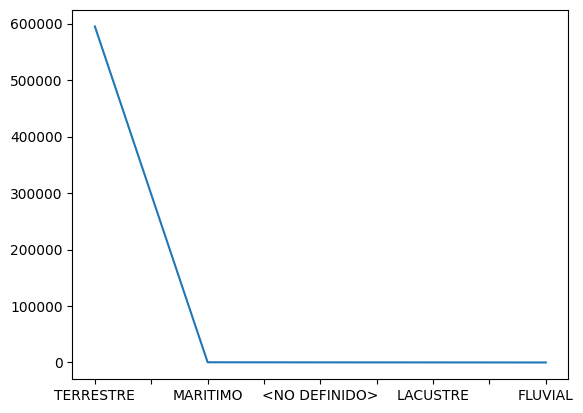

In [6]:
# Campos: ['Id Mov Migratorio', 'Fecha Control', 'Tipo Movimiento', 'Via Transporte', 'Dependencia']
      
df_1_1 = df_1.groupby(by=['Via Transporte']).agg({ 'Id Mov Migratorio': [np.ma.count] }) \
             .droplevel(level=0, axis=1) \
             .sort_values(by='count', ascending=False) \

df_1_1.plot(legend=False, xlabel='')

### 3.2 Se define como regla que, el país de origen del movimiento migratorio de entrada debe ser diferente a `Perú`.

In [27]:
df_2 = pd.read_excel('./data/A2.xlsx')

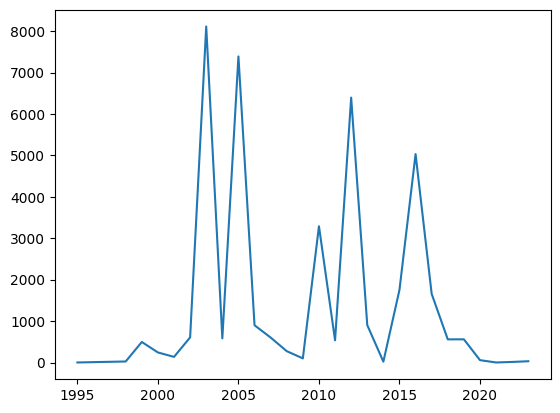

In [28]:
# Columns: ['Id Mov Migratorio', 'Fecha Control', 'Tipo Movimiento', 'Pais Movimiento']

df_2['Año Control'] = df_2['Fecha Control'].dt.year

df_2_f = df_2.groupby(by=['Año Control']).agg({ 'Id Mov Migratorio': [np.ma.count] }).droplevel(level=0, axis=1)
df_2_f = df_2_f.plot(legend=False, xlabel='')


### 3.3 Se define como regla que, el país de destino del movimiento migratorio de salida debe ser diferente a `Perú`.

In [29]:
df_3 = pd.read_excel('./data/A3.xlsx')

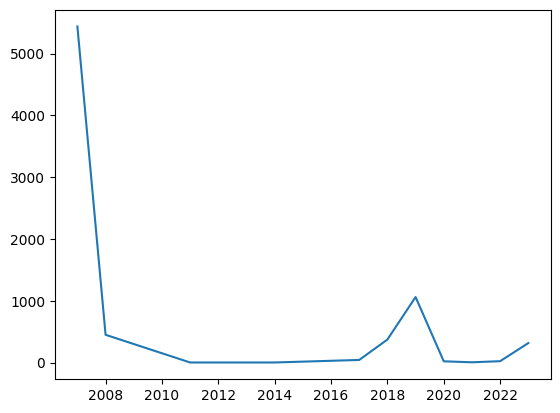

In [38]:
# Columns: ['Id Mov Migratorio', 'Fecha Control', 'Tipo Movimiento', 'Pais Movimiento']

df_3['Año Control'] = df_3['Fecha Control'].dt.year

df_3_f = df_3.groupby(by=['Año Control']).agg({ 'Id Mov Migratorio': [np.ma.count] }).droplevel(level=0, axis=1).head(11)
df_3_f = df_3_f.plot(legend=False, xlabel='')

### 3.4 Se define como regla que, si el control migratorio está activo, el itinerario no debe estar cancelado.

In [41]:
df_3 = pd.read_excel('./data/A4.xlsx')

<Axes: >

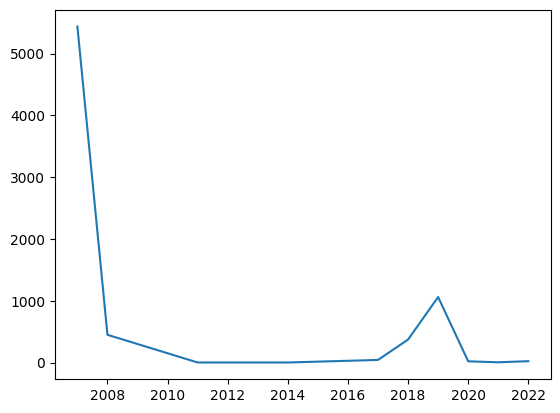

In [42]:
# Columns: ['Id Mov Migratorio', 'Fecha Control', 'Tipo Movimiento', 'Estado Movimiento', 'Estado Itinerario']

df_3['Año Control'] = df_3['Fecha Control'].dt.year

df_3_1 = df_3.groupby(by=['Año Control']).agg({ 'Id Mov Migratorio': [np.ma.count] }) \
             .droplevel(level=0, axis=1) \
             .head(10)

df_3_1.plot(legend=False, xlabel='')

### 3.5 Se define como regla que, los datos de la persona asociados al trámite en la base central de pasaportes deben ser iguales a los datos de la persona asociados al trámite en el Sistema de Iintegral de Migraciones (SIM).

In [45]:
df_5 = pd.read_excel('./data/A5.xlsx')

<Axes: >

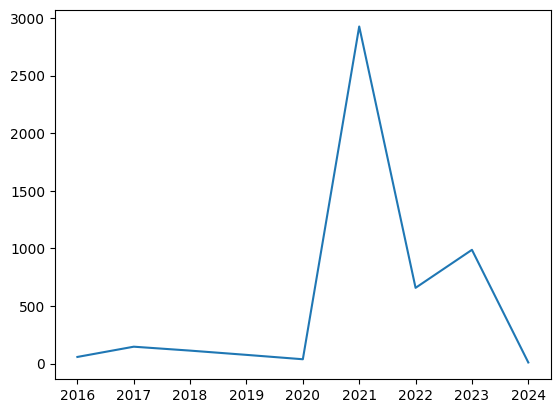

In [47]:
# columns: ['Número Trámite(SIM)', 'Número Trámite(Base Central)', 'Nombre (Base Central)', 'Año Emisión (Base Central)']

df_5['Año Emisión'] = df_5['Año Emisión (Base Central)'].dt.year

df_5_1 = df_5.groupby(by=['Año Emisión']).agg({ 'Número Trámite(SIM)': [np.ma.count] }) \
             .droplevel(level=0, axis=1) \
             .head(10)

df_5_1.plot(legend=False, xlabel='')
